<a href="https://colab.research.google.com/github/ipriyanshuyadav21/apl_priyanshy/blob/main/apsLab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

In [36]:
data = load_breast_cancer()

X = pd.DataFrame(
    data.data, columns = data.feature_names
)
y = pd.Series(
    (data.target == 0).astype(int),name ="malignant"
)
print(y.value_counts())

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Class names:", data.target_names)

malignant
0    357
1    212
Name: count, dtype: int64
Feature matrix shape: (569, 30)
Target shape: (569,)
Class names: ['malignant' 'benign']


In [37]:

class_counts = y.value_counts().sort_index()
class_distribution = pd.DataFrame({"Class": data.target_names,
    "Count": class_counts.values,
    "Probability":class_counts.values / len(y)
})
print(class_distribution)

       Class  Count  Probability
0  malignant    357     0.627417
1     benign    212     0.372583


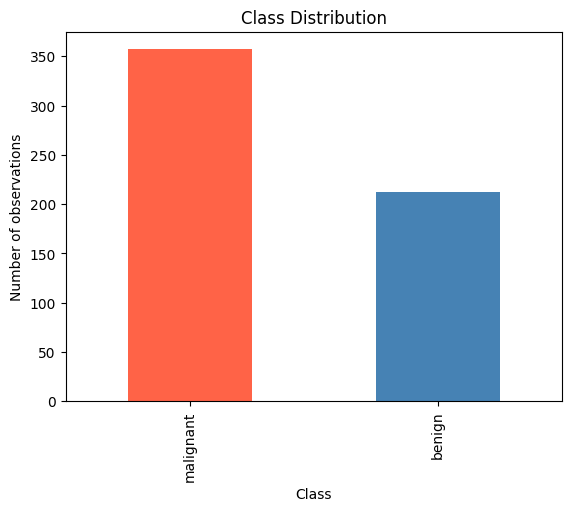

In [38]:

class_distribution.plot(
    x = "Class", y = "Count", kind = "bar", legend = False, color = ["tomato","steelblue"]
)

plt.ylabel("Number of observations")
plt.title("Class Distribution")
plt.show()

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify=y
)
print("Training size:", len(y_train))
print("Testing size:", len(y_test))
print("\nTraining proportions:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTesting proportions:")
print(y_test.value_counts(normalize=True).sort_index())

Training size: 455
Testing size: 114

Training proportions:
malignant
0    0.626374
1    0.373626
Name: proportion, dtype: float64

Testing proportions:
malignant
0    0.631579
1    0.368421
Name: proportion, dtype: float64


In [40]:
model =make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))

model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [41]:

#Obtain predicted probabilities
probabilities = model.predict_proba(X_test)

print(probabilities[:5])

[[9.99635432e-01 3.64568116e-04]
 [1.07465986e-08 9.99999989e-01]
 [9.57432053e-01 4.25679471e-02]
 [4.23812678e-01 5.76187322e-01]
 [4.90844511e-01 5.09155489e-01]]


In [42]:

results = pd.DataFrame({
    "Actual_class": y_test.values,
    "P_malignant": probabilities[:,0],
    "P_benign": probabilities[:,1]
})
print(results.head(10))


   Actual_class   P_malignant  P_benign
0             0  9.996354e-01  0.000365
1             1  1.074660e-08  1.000000
2             0  9.574321e-01  0.042568
3             1  4.238127e-01  0.576187
4             0  4.908445e-01  0.509155
5             0  9.993840e-01  0.000616
6             1  2.384659e-01  0.761534
7             0  9.989878e-01  0.001012
8             0  9.994313e-01  0.000569
9             0  9.892324e-01  0.010768


In [43]:
results = pd.DataFrame({
    "Actual_class": y_test.values,
    "P_malignant": probabilities[:,0],
    "P_benign": probabilities[:,1]
})
print(results.head(10))

   Actual_class   P_malignant  P_benign
0             0  9.996354e-01  0.000365
1             1  1.074660e-08  1.000000
2             0  9.574321e-01  0.042568
3             1  4.238127e-01  0.576187
4             0  4.908445e-01  0.509155
5             0  9.993840e-01  0.000616
6             1  2.384659e-01  0.761534
7             0  9.989878e-01  0.001012
8             0  9.994313e-01  0.000569
9             0  9.892324e-01  0.010768


In [44]:
results["Actual_label"] = results["Actual_class"].map({
    0: "malignant",
    1: "benign"
})
print(results[
    ["Actual_label","P_malignant","P_benign"]
].head(10))


  Actual_label   P_malignant  P_benign
0    malignant  9.996354e-01  0.000365
1       benign  1.074660e-08  1.000000
2    malignant  9.574321e-01  0.042568
3       benign  4.238127e-01  0.576187
4    malignant  4.908445e-01  0.509155
5    malignant  9.993840e-01  0.000616
6       benign  2.384659e-01  0.761534
7    malignant  9.989878e-01  0.001012
8    malignant  9.994313e-01  0.000569
9    malignant  9.892324e-01  0.010768


In [15]:
threshold = 0.50

results["Predicted_malignant"] = (
    results["P_malignant"] >= threshold
).astype(int)
results["Predicted_label"]= results["Predicted_malignant"].map({
    0: "malignant",
    1: "benign"
})

print(
    results[
        ["Actual_label","P_malignant","Predicted_label"]
    ].head(10)
)


  Actual_label   P_malignant Predicted_label
0    malignant  9.996354e-01          benign
1       benign  1.074660e-08       malignant
2    malignant  9.574321e-01          benign
3       benign  4.238127e-01       malignant
4    malignant  4.908445e-01       malignant
5    malignant  9.993840e-01          benign
6       benign  2.384659e-01       malignant
7    malignant  9.989878e-01          benign
8    malignant  9.994313e-01          benign
9    malignant  9.892324e-01          benign


In [16]:
for threshold in [0.3,0.5,0.7]:
  predictions = (
      results["P_malignant"] >= threshold
  ).astype(int)
  print("Threshold:", threshold)
  print(f"Predicted malignant cases = {predictions.sum()}")



Threshold: 0.3
Predicted malignant cases = 76
Threshold: 0.5
Predicted malignant cases = 74
Threshold: 0.7
Predicted malignant cases = 72


In [18]:
actual_malignant = (y_test.values==0).astype(int)
for threshold in (0.30,0.50,0.70):
  predicted_malignant = (
      probabilities[:,0]>=threshold
  ).astype(int)
  cm=confusion_matrix(
      actual_malignant,
      predicted_malignant
  )
  print(f"\nThreshold",threshold)
  print(cm)


Threshold 0.3
[[38  4]
 [ 0 72]]

Threshold 0.5
[[39  3]
 [ 1 71]]

Threshold 0.7
[[41  1]
 [ 1 71]]


In [29]:
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
print(accuracy_score(y_test,y_pred))
print(precision_score(y_test,y_pred))
print(recall_score(y_test,y_pred))

0.9649122807017544
0.975
0.9285714285714286


In [35]:
import pandas as pd
from sklearn.metrics import confusion_matrix

# Compare all metrics across thresholds
metric_results = []

for threshold in [0.10, 0.30, 0.50, 0.70, 0.90]:

    # Convert probabilities to predicted class
    y_pred_threshold = (
        probabilities[:, 1] >= threshold
    ).astype(int)

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred_threshold,
        labels=[0, 1]
    ).ravel()

    # Calculate metrics
    accuracy = (tp + tn) / (tp + tn + fp + fn)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0

    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0
    )

    # Store results
    metric_results.append([
        threshold,
        accuracy,
        precision,
        recall,
        specificity,
        f1
    ])


# Create table
threshold_metrics = pd.DataFrame(
    metric_results,
    columns=[
        "Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "Specificity",
        "F1 Score"
    ]
)

# Display table
display(threshold_metrics.round(3))






,Threshold,Accuracy,Precision,Recall,Specificity,F1 Score
0,0.1,0.947,0.891,0.976,0.931,0.932
1,0.3,0.982,0.976,0.976,0.986,0.976
2,0.5,0.965,0.975,0.929,0.986,0.951
3,0.7,0.965,1.000,0.905,1.000,0.950
4,0.9,0.921,1.000,0.786,1.000,0.880


NameError: name 'thresholds' is not defined